In [1]:
import pydicom
import os
from os import listdir
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import scipy as sp
from functools import partial
from tqdm.notebook import tqdm

%matplotlib inline


In [2]:
im_path = "../input/osic-pulmonary-fibrosis-progressiont/"
train_df = pd.read_csv('../input/osic-pulmonary-fibrosis-progression/train.csv')
test_df = pd.read_csv('../input/osic-pulmonary-fibrosis-progression/test.csv')
print('Training data shape: ', train_df.shape)
train_df.head()


Training data shape:  (1394, 7)


,Patient,Weeks,FVC,Percent,Age,Sex,SmokingStatus
0,ID00133637202223847701934,-2,3195,92.856312,83,Male,Never smoked
1,ID00133637202223847701934,2,3203,93.088817,83,Male,Never smoked
2,ID00133637202223847701934,4,3097,90.008138,83,Male,Never smoked
3,ID00133637202223847701934,6,3171,92.158800,83,Male,Never smoked
4,ID00133637202223847701934,8,3115,90.531272,83,Male,Never smoked


In [3]:
# construct train input
train_df['Patient_Week'] = train_df['Patient'].astype(str) + '_' + train_df['Weeks'].astype(str)
output = pd.DataFrame()
gb = train_df.groupby('Patient')
tk0 = tqdm(gb, total=len(gb))
for _, usr_df in tk0:
    usr_output = pd.DataFrame()
    for week, tmp in usr_df.groupby('Weeks'):
        rename_cols = {'Weeks': 'base_Week', 'FVC': 'base_FVC', 'Percent': 'base_Percent', 'Age': 'base_Age'}
        tmp = tmp.drop(columns='Patient_Week').rename(columns=rename_cols)
        drop_cols = ['Age', 'Sex', 'SmokingStatus', 'Percent']
        _usr_output = usr_df.drop(columns=drop_cols).rename(columns={'Weeks': 'predict_Week'}).merge(tmp, on='Patient')
        _usr_output['Week_passed'] = _usr_output['predict_Week'] - _usr_output['base_Week']
        usr_output = pd.concat([usr_output, _usr_output])
    output = pd.concat([output, usr_output])
    
train_df = output[output['Week_passed']!=0].reset_index(drop=True)
print(train_df.shape)
train_df.head()


  0%|          | 0/158 [00:00<?, ?it/s]

(10952, 11)


,Patient,predict_Week,FVC,Patient_Week,base_Week,base_FVC,base_Percent,base_Age,Sex,SmokingStatus,Week_passed
0,ID00007637202177411956430,5,2214,ID00007637202177411956430_5,-4,2315,58.253649,79,Male,Ex-smoker,9
1,ID00007637202177411956430,7,2061,ID00007637202177411956430_7,-4,2315,58.253649,79,Male,Ex-smoker,11
2,ID00007637202177411956430,9,2144,ID00007637202177411956430_9,-4,2315,58.253649,79,Male,Ex-smoker,13
3,ID00007637202177411956430,11,2069,ID00007637202177411956430_11,-4,2315,58.253649,79,Male,Ex-smoker,15
4,ID00007637202177411956430,17,2101,ID00007637202177411956430_17,-4,2315,58.253649,79,Male,Ex-smoker,21


In [4]:
train_df = pd.get_dummies(train_df, columns=['Sex'])
train_df = pd.get_dummies(train_df, columns=['SmokingStatus'])
train_df = train_df.rename(columns={"Sex_Female": "Female", 
                                    "Sex_Male": "Male",
                                    "SmokingStatus_Currently smokes": "CurrentlySmokes",
                                    "SmokingStatus_Ex-smoker": "ExSmoker",
                                    "SmokingStatus_Never smoked": "NeverSmoked"})
train_df.head()


,Patient,predict_Week,FVC,Patient_Week,base_Week,base_FVC,base_Percent,base_Age,Week_passed,Female,Male,CurrentlySmokes,ExSmoker,NeverSmoked
0,ID00007637202177411956430,5,2214,ID00007637202177411956430_5,-4,2315,58.253649,79,9,False,True,False,True,False
1,ID00007637202177411956430,7,2061,ID00007637202177411956430_7,-4,2315,58.253649,79,11,False,True,False,True,False
2,ID00007637202177411956430,9,2144,ID00007637202177411956430_9,-4,2315,58.253649,79,13,False,True,False,True,False
3,ID00007637202177411956430,11,2069,ID00007637202177411956430_11,-4,2315,58.253649,79,15,False,True,False,True,False
4,ID00007637202177411956430,17,2101,ID00007637202177411956430_17,-4,2315,58.253649,79,21,False,True,False,True,False


In [5]:
X = train_df.drop(['Patient','FVC','base_Week','predict_Week','Patient_Week'], axis=1)
y = train_df['FVC']


In [6]:
# Splite data into training and testing
from sklearn import model_selection

# Reserve 20% for testing
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.2, shuffle = False)

print('training data has ' + str(X_train.shape[0]) + 
      ' observation with ' + str(X_train.shape[1]) + ' features')
print('test data has ' + str(X_test.shape[0]) + 
      ' observation with ' + str(X_test.shape[1]) + ' features')


training data has 8761 observation with 9 features
test data has 2191 observation with 9 features


In [7]:
# standardization (x-mean)/std
# normalization (x-x_min)/(x_max-x_min) ->[0,1]

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)


In [8]:
import xgboost as xgb
from xgboost import XGBRegressor
regr_XGB = XGBRegressor()


In [9]:
regr_XGB.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [10]:
from sklearn import model_selection
from sklearn.model_selection import GridSearchCV


In [11]:
regr_XGB_opt = XGBRegressor(base_score=0.5, booster='gbtree', colsample_bylevel=1,
             colsample_bynode=1, colsample_bytree=0.8999999999999999, eta=0.01,
             gamma=0, gpu_id=-1, importance_type='gain',
             interaction_constraints='', learning_rate=0.300000012,
             max_delta_step=0, max_depth=5, min_child_weight=1, missing=None,
             monotone_constraints='()', n_estimators=100, n_jobs=0,
             num_parallel_tree=1, random_state=0, reg_alpha=0, reg_lambda=1,
             scale_pos_weight=1, subsample=0.7999999999999999,
             tree_method='exact', validate_parameters=1, verbosity=None)


In [12]:
regr_XGB_opt.fit(X_train, y_train)
y_pred = regr_XGB_opt.predict(X_test)


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:160: UserWarning: [01:22:57] WARNING: /workspace/src/common/error_msg.cc:45: `gpu_id` is deprecated since2.0.0, use `device` instead. E.g. device=cpu/cuda/cuda:0
  warnings.warn(smsg, UserWarning)


XGBoostError: [01:22:58] /workspace/include/xgboost/json.h:630: Invalid type for: `missing`, expecting one of the: {``Number`, `Integer`}, got: `Null`
Stack trace:
  [bt] (0) /usr/local/lib/python3.11/dist-packages/xgboost/lib/libxgboost.so(+0x15c2ca) [0x7fff7e1c12ca]
  [bt] (1) /usr/local/lib/python3.11/dist-packages/xgboost/lib/libxgboost.so(+0x194354) [0x7fff7e1f9354]
  [bt] (2) /usr/local/lib/python3.11/dist-packages/xgboost/lib/libxgboost.so(+0x1944b8) [0x7fff7e1f94b8]
  [bt] (3) /usr/local/lib/python3.11/dist-packages/xgboost/lib/libxgboost.so(+0x16d5d8) [0x7fff7e1d25d8]
  [bt] (4) /usr/local/lib/python3.11/dist-packages/xgboost/lib/libxgboost.so(XGBoosterPredictFromDense+0x2ab) [0x7fff7e1d2dcb]
  [bt] (5) /lib/x86_64-linux-gnu/libffi.so.8(+0x7e2e) [0x7ffff63ace2e]
  [bt] (6) /lib/x86_64-linux-gnu/libffi.so.8(+0x4493) [0x7ffff63a9493]
  [bt] (7) /usr/lib/python3.11/lib-dynload/_ctypes.cpython-311-x86_64-linux-gnu.so(+0xa4d8) [0x7ffff63bc4d8]
  [bt] (8) /usr/lib/python3.11/lib-dyn

In [13]:
plt.figure(figsize=(5,5))
plt.scatter(y_test, y_pred,color = 'r', alpha = 0.3)
plt.plot([min(y_test),max(y_test)],[min(y_test),max(y_test)], color = 'k')
plt.xlabel('FVC$_{\mathrm{test}}$')
plt.ylabel('FVC$_{\mathrm{pred}}$')
plt.rcParams.update({'font.size': 22})


NameError: name 'y_pred' is not defined

<Figure size 500x500 with 0 Axes>

In [14]:
from sklearn.metrics import mean_squared_error
mse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE: %f" % (mse**0.5))


NameError: name 'y_pred' is not defined

In [15]:
data_dmatrix = xgb.DMatrix(data=X,label=y)
params = {"objective":"reg:squarederror",'colsample_bytree': 0.3,'learning_rate': 0.1,
                'max_depth': 5, 'alpha': 10}
cv_results = xgb.cv(dtrain=data_dmatrix, params=params, nfold=10,
                    num_boost_round=200,early_stopping_rounds=10,metrics="rmse", as_pandas=True, seed=123)
print((cv_results["test-rmse-mean"]).tail(1))


199    205.282152
Name: test-rmse-mean, dtype: float64


In [16]:
importances = regr_XGB.feature_importances_
indices = np.argsort(importances)[::-1]
# Print the feature ranking
print("Feature importance ranking by XGBoost Model:")
for ind in range(X.shape[1]):
    print ("%s : %.4f" %(X.columns[indices[ind]],importances[indices[ind]]))


Feature importance ranking by XGBoost Model:
base_FVC : 0.8032
CurrentlySmokes : 0.0635
NeverSmoked : 0.0305
ExSmoker : 0.0258
base_Age : 0.0231
Female : 0.0213
base_Percent : 0.0190
Week_passed : 0.0136
Male : 0.0000


<Axes: >

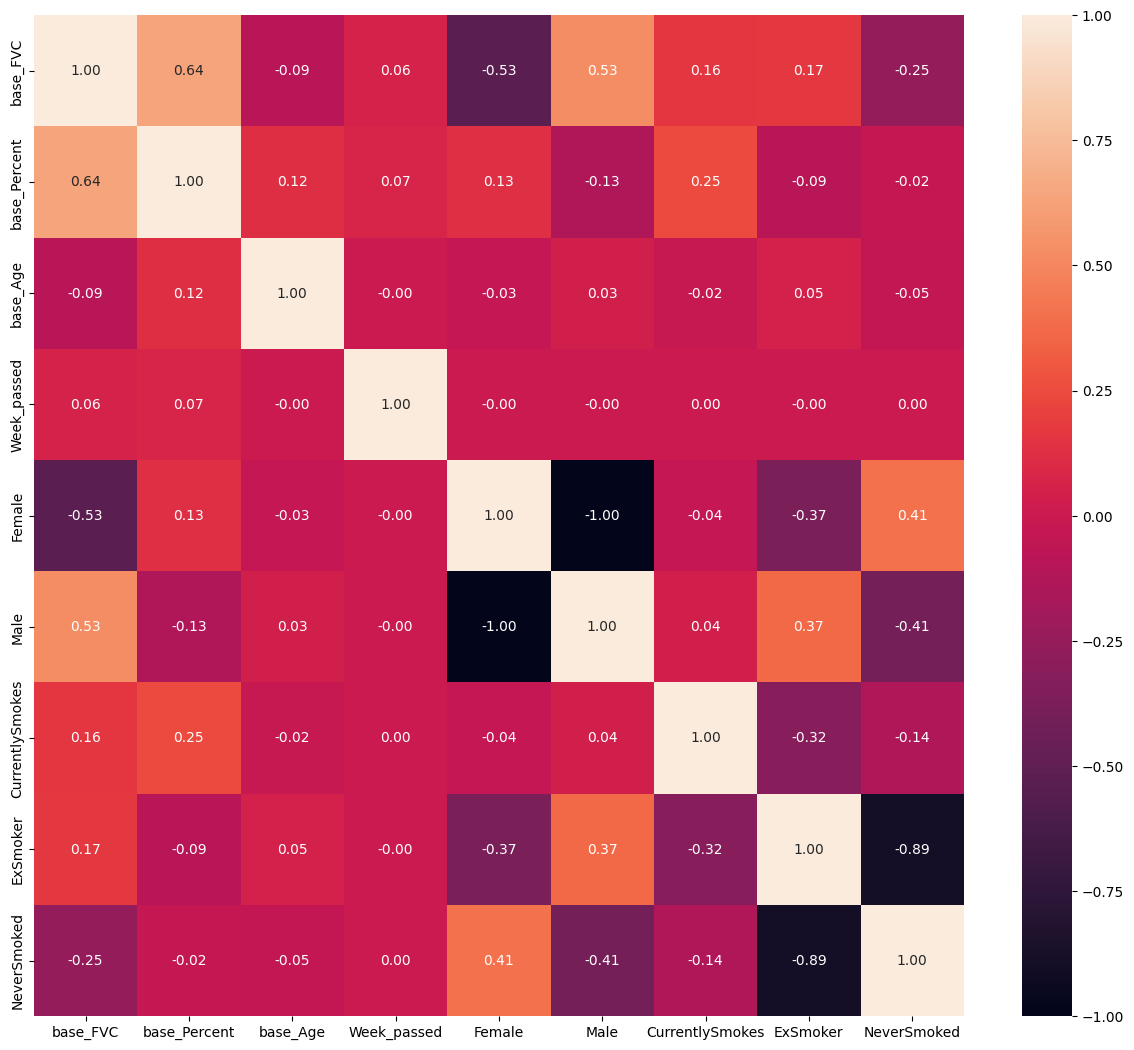

In [17]:
import seaborn as sns
fig, ax = plt.subplots(figsize=(15,13)) 
sns.heatmap(X.corr(), annot = True, fmt = '.2f')


In [18]:
FVC_pred_train = regr_XGB_opt.predict(X_train)
train_df = pd.DataFrame(X_train, columns = X.columns)
train_df['FVC'] = y_train
train_df['FVC_pred'] = FVC_pred_train

FVC_pred_test = regr_XGB_opt.predict(X_test)
test_df = pd.DataFrame(X_test, columns = X.columns)
test_df['FVC'] = np.asarray(y_test)
test_df['FVC_pred'] = FVC_pred_test


XGBoostError: [01:23:00] /workspace/include/xgboost/json.h:630: Invalid type for: `missing`, expecting one of the: {``Number`, `Integer`}, got: `Null`
Stack trace:
  [bt] (0) /usr/local/lib/python3.11/dist-packages/xgboost/lib/libxgboost.so(+0x15c2ca) [0x7fff7e1c12ca]
  [bt] (1) /usr/local/lib/python3.11/dist-packages/xgboost/lib/libxgboost.so(+0x194354) [0x7fff7e1f9354]
  [bt] (2) /usr/local/lib/python3.11/dist-packages/xgboost/lib/libxgboost.so(+0x1944b8) [0x7fff7e1f94b8]
  [bt] (3) /usr/local/lib/python3.11/dist-packages/xgboost/lib/libxgboost.so(+0x16d5d8) [0x7fff7e1d25d8]
  [bt] (4) /usr/local/lib/python3.11/dist-packages/xgboost/lib/libxgboost.so(XGBoosterPredictFromDense+0x2ab) [0x7fff7e1d2dcb]
  [bt] (5) /lib/x86_64-linux-gnu/libffi.so.8(+0x7e2e) [0x7ffff63ace2e]
  [bt] (6) /lib/x86_64-linux-gnu/libffi.so.8(+0x4493) [0x7ffff63a9493]
  [bt] (7) /usr/lib/python3.11/lib-dynload/_ctypes.cpython-311-x86_64-linux-gnu.so(+0xa4d8) [0x7ffff63bc4d8]
  [bt] (8) /usr/lib/python3.11/lib-dyn

In [19]:
# baseline score
train_df['Confidence'] = 100
train_df['sigma_clipped'] = train_df['Confidence'].apply(lambda x: max(x, 70))
train_df['diff'] = abs(train_df['FVC'] - train_df['FVC_pred'])
train_df['delta'] = train_df['diff'].apply(lambda x: min(x, 1000))
train_df['score'] = -2**0.5*train_df['delta']/train_df['sigma_clipped'] - np.log(2**0.5*train_df['sigma_clipped'])
score = train_df['score'].mean()
print(score)


KeyError: 'FVC_pred'

In [20]:
def loss_func(weight, row):
    confidence = weight
    sigma_clipped = max(confidence, 70)
    diff = abs(row['FVC'] - row['FVC_pred'])
    delta = min(diff, 1000)
    score = -2**0.5*delta/sigma_clipped - np.log(2**0.5*sigma_clipped)
    return -score

results = []
tk0 = tqdm(test_df.iterrows(), total=len(test_df))
for _, row in tk0:
    loss_partial = partial(loss_func, row=row)
    weight = [100]
    #bounds = [(70, 100)]
    #result = sp.optimize.minimize(loss_partial, weight, method='SLSQP', bounds=bounds)
    result = sp.optimize.minimize(loss_partial, weight, method='SLSQP')
    x = result['x']
    results.append(x[0])


  0%|          | 0/18 [00:00<?, ?it/s]

KeyError: 'FVC_pred'

In [21]:
test_df['Confidence'] = results
test_df['sigma_clipped'] = test_df['Confidence'].apply(lambda x: max(x, 70))
test_df['diff'] = abs(test_df['FVC'] - test_df['FVC_pred'])
test_df['delta'] = test_df['diff'].apply(lambda x: min(x, 1000))
test_df['score'] = -2**0.5*test_df['delta']/test_df['sigma_clipped'] - np.log(2**0.5*test_df['sigma_clipped'])
score = test_df['score'].mean()
print(score)


ValueError: Length of values (0) does not match length of index (18)

In [22]:
test = pd.read_csv('../input/osic-pulmonary-fibrosis-progression/test.csv')\
        .rename(columns={'Weeks': 'base_Week', 'FVC': 'base_FVC', 'Percent': 'base_Percent', 'Age': 'base_Age'})
submission = pd.read_csv('../input/osic-pulmonary-fibrosis-progression/sample_submission.csv')
submission['Patient'] = submission['Patient_Week'].apply(lambda x: x.split('_')[0])
submission['predict_Week'] = submission['Patient_Week'].apply(lambda x: x.split('_')[1]).astype(int)
test = submission.drop(columns=['FVC', 'Confidence']).merge(test, on='Patient')
test['Week_passed'] = test['predict_Week'] - test['base_Week']
print(test.shape)
test.head()


(1908, 10)


,Patient_Week,Patient,predict_Week,base_Week,base_FVC,base_Percent,base_Age,Sex,SmokingStatus,Week_passed
0,ID00126637202218610655908_-3,ID00126637202218610655908,-3,18,2375,59.375,78,Male,Ex-smoker,-21
1,ID00126637202218610655908_-2,ID00126637202218610655908,-2,18,2375,59.375,78,Male,Ex-smoker,-20
2,ID00126637202218610655908_-1,ID00126637202218610655908,-1,18,2375,59.375,78,Male,Ex-smoker,-19
3,ID00126637202218610655908_0,ID00126637202218610655908,0,18,2375,59.375,78,Male,Ex-smoker,-18
4,ID00126637202218610655908_1,ID00126637202218610655908,1,18,2375,59.375,78,Male,Ex-smoker,-17


In [23]:
test = pd.get_dummies(test, columns=['Sex'])
test = pd.get_dummies(test, columns=['SmokingStatus'])
test = test.rename(columns={"Sex_Female": "Female", 
                                    "Sex_Male": "Male",
                                    "SmokingStatus_Currently smokes": "CurrentlySmokes",
                                    "SmokingStatus_Ex-smoker": "ExSmoker",
                                    "SmokingStatus_Never smoked": "NeverSmoked"})


In [24]:
submission = pd.read_csv('../input/osic-pulmonary-fibrosis-progression/sample_submission.csv')
submission


,Patient_Week,FVC,Confidence
0,ID00126637202218610655908_-3,2000,100
1,ID00126637202218610655908_-2,2000,100
2,ID00126637202218610655908_-1,2000,100
3,ID00126637202218610655908_0,2000,100
4,ID00126637202218610655908_1,2000,100
...,...,...,...
1903,ID00047637202184938901501_98,2000,100
1904,ID00047637202184938901501_99,2000,100
1905,ID00047637202184938901501_100,2000,100
1906,ID00047637202184938901501_101,2000,100


In [25]:
submission = pd.read_csv('../input/osic-pulmonary-fibrosis-progression/sample_submission.csv')
submission['Patient'] = submission['Patient_Week'].apply(lambda x: x.split('_')[0])
submission['predict_Week'] = submission['Patient_Week'].apply(lambda x: x.split('_')[1]).astype(int)
submission.head()


,Patient_Week,FVC,Confidence,Patient,predict_Week
0,ID00126637202218610655908_-3,2000,100,ID00126637202218610655908,-3
1,ID00126637202218610655908_-2,2000,100,ID00126637202218610655908,-2
2,ID00126637202218610655908_-1,2000,100,ID00126637202218610655908,-1
3,ID00126637202218610655908_0,2000,100,ID00126637202218610655908,0
4,ID00126637202218610655908_1,2000,100,ID00126637202218610655908,1


In [26]:
# sub = submission.drop(columns=['FVC', 'Confidence']).merge(test[['Patient_Week', 'FVC_pred', 'Confidence']], 
#                                                            on='Patient_Week')
sub = submission.drop(columns=['Patient','predict_Week','FVC', 'Confidence']).merge(test, on='Patient_Week')
# sub.columns = submission.columns
sub.to_csv('submission.csv', index=False)
sub['Female'] = 0
sub['CurrentlySmokes'] = 0
sub = sub[['Patient_Week', 'Patient', 'predict_Week', 'base_Week', 'base_FVC', 'base_Percent', 'base_Age', 
           'Week_passed', 'Female', 'Male', 'CurrentlySmokes', 'ExSmoker', 'NeverSmoked']]


In [27]:
X_test_sub = sub.iloc[:,4:]
scaler = MinMaxScaler()
scaler.fit(X_test_sub)
X_test_sub = scaler.transform(X_test_sub)
FVC_pred_sub = regr_XGB_opt.predict(X_test_sub)
sub['FVC_pred'] = FVC_pred_sub 
sub


XGBoostError: [01:23:00] /workspace/include/xgboost/json.h:630: Invalid type for: `missing`, expecting one of the: {``Number`, `Integer`}, got: `Null`
Stack trace:
  [bt] (0) /usr/local/lib/python3.11/dist-packages/xgboost/lib/libxgboost.so(+0x15c2ca) [0x7fff7e1c12ca]
  [bt] (1) /usr/local/lib/python3.11/dist-packages/xgboost/lib/libxgboost.so(+0x194354) [0x7fff7e1f9354]
  [bt] (2) /usr/local/lib/python3.11/dist-packages/xgboost/lib/libxgboost.so(+0x1944b8) [0x7fff7e1f94b8]
  [bt] (3) /usr/local/lib/python3.11/dist-packages/xgboost/lib/libxgboost.so(+0x16d5d8) [0x7fff7e1d25d8]
  [bt] (4) /usr/local/lib/python3.11/dist-packages/xgboost/lib/libxgboost.so(XGBoosterPredictFromDense+0x2ab) [0x7fff7e1d2dcb]
  [bt] (5) /lib/x86_64-linux-gnu/libffi.so.8(+0x7e2e) [0x7ffff63ace2e]
  [bt] (6) /lib/x86_64-linux-gnu/libffi.so.8(+0x4493) [0x7ffff63a9493]
  [bt] (7) /usr/lib/python3.11/lib-dynload/_ctypes.cpython-311-x86_64-linux-gnu.so(+0xa4d8) [0x7ffff63bc4d8]
  [bt] (8) /usr/lib/python3.11/lib-dyn

In [28]:
for pid in sub['Patient'].unique():
# pid = 'ID00426637202313170790466'
    temp = sub[sub['Patient'] == pid]
    plt.plot(temp['predict_Week'], temp['FVC_pred'])


KeyError: 'FVC_pred'

In [29]:
attempt1 = submission.merge(sub, on='Patient_Week')
attempt1 = attempt1.loc[:,['Patient_Week','FVC_pred','Confidence']]
attempt1.columns = ['Patient_Week','FVC','Confidence']
attempt1['Confidence'] = 500
attempt1.to_csv('submission.csv', index=False)


KeyError: "['FVC_pred'] not in index"